# 04b - Extended Alpha Sweep

Addresses mentor feedback: the original sweep (1 to 10,000) had not
plateaued for any layer, so alpha=10000 was only the best value tested,
not necessarily the true optimum. This extends the range to 1,000,000
and plots where each layer's curve actually levels off.

This version self-extracts AlexNet activations if the cache is
missing (e.g. a fresh Colab session), instead of requiring notebook 02
to be run first.

In [ ]:
!git clone https://github.com/sossyh/ffa-dnn-ablation.git
%cd ffa-dnn-ablation

Cloning into 'ffa-dnn-ablation'...
remote: Enumerating objects: 158, done.
remote: Counting objects: 100% (158/158), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 158 (delta 83), reused 126 (delta 55), pack-reused 0 (from 0)
Receiving objects: 100% (158/158), 458.79 KiB | 22.94 MiB/s, done.
Resolving deltas: 100% (83/83), done.
/content/ffa-dnn-ablation


In [ ]:
!pip install nilearn decord python-dotenv --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.


In [ ]:
import os
from google.colab import userdata

os.environ["DROPBOX_DATASET_LINK"] = userdata.get("DROPBOX_DATASET_LINK")

In [ ]:
import sys
sys.path.append(".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

from src.data_loading import (
    download_algonauts_data,
    load_all_rois,
    get_video_list,
    load_video_frames,
)
from src.models.alexnet_wrapper import AlexNetWrapper

In [ ]:
download_algonauts_data(data_dir="data/raw")

fmri_dir = "data/raw/participants_data_v2021/mini_track"
subject = "sub01"
roi_data = load_all_rois(fmri_dir, subject)

NUM_TRAIN_VIDEOS = roi_data["FFA"].shape[0]
print("FFA shape:", roi_data["FFA"].shape)

Download complete.
FFA shape: (1000, 68)


## Load or extract AlexNet activations

If the cache from notebook 02 exists, load it. Otherwise, extract from
scratch here (this takes a few minutes on T4) and save the cache, so
any future notebook in this session can reuse it.

In [ ]:
os.makedirs("data/processed", exist_ok=True)
activation_cache_path = "data/processed/alexnet_activations.npz"

need_to_extract = True

if os.path.exists(activation_cache_path):
    cached = np.load(activation_cache_path, allow_pickle=True)
    all_activations = cached["all_activations"].item()
    cached_num_videos = next(iter(all_activations.values())).shape[0]

    if cached_num_videos == NUM_TRAIN_VIDEOS:
        print("Loaded cached activations.")
        need_to_extract = False
    else:
        print("Cache is stale (video count mismatch), re-extracting.")
else:
    print("No cache found, extracting from scratch.")

if need_to_extract:
    video_dir = "data/raw/AlgonautsVideos268_All_30fpsmax"
    video_paths = get_video_list(video_dir)[:NUM_TRAIN_VIDEOS]

    assert len(video_paths) == NUM_TRAIN_VIDEOS, (
        f"Video count ({len(video_paths)}) does not match fMRI row count "
        f"({NUM_TRAIN_VIDEOS})."
    )

    alexnet = AlexNetWrapper()
    all_activations = {layer: [] for layer in alexnet.layers}

    for video_path in tqdm(video_paths):
        frames = load_video_frames(video_path, num_frames=8)
        layer_acts = alexnet.extract(frames)
        for layer in alexnet.layers:
            all_activations[layer].append(layer_acts[layer])

    for layer in all_activations:
        all_activations[layer] = np.stack(all_activations[layer])

    np.savez(activation_cache_path, all_activations=all_activations)
    print("Extraction complete and cached.")

for layer, acts in all_activations.items():
    assert acts.shape[0] == NUM_TRAIN_VIDEOS, f"Layer {layer} shape mismatch."

print("\nAll shapes confirmed. Ready to proceed.")

No cache found, extracting from scratch.
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 120MB/s]
100%|██████████| 1000/1000 [01:28<00:00, 11.33it/s]


Extraction complete and cached.

All shapes confirmed. Ready to proceed.


## Evaluation function

Same nested-CV structure as production: standardization fit only on
the outer training fold, evaluated with a single fixed alpha per call
(here we sweep the fixed alpha manually, layer by layer, purely to
visualize where accuracy plateaus).

In [ ]:
def evaluate_fixed_alpha(X, Y, alpha, n_folds=5, seed=42):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    num_voxels = Y.shape[1]
    fold_scores = np.zeros((n_folds, num_voxels))

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = Ridge(alpha=alpha)
        model.fit(X_train, Y_train)
        Y_pred = model.predict(X_test)

        for v in range(num_voxels):
            r, _ = pearsonr(Y_test[:, v], Y_pred[:, v])
            fold_scores[fold_idx, v] = r if not np.isnan(r) else 0.0

    return fold_scores.mean(axis=0)

## Extended sweep: 1 to 1,000,000, for FFA specifically

These correlations are for one ROI (FFA), not averaged across all
ROIs. Each layer gets its own curve, so you can see where each one
individually plateaus.

In [ ]:
alphas = np.logspace(0, 6, 13)  # 1 to 1,000,000
layers_to_check = ["conv5", "fc6", "fc7", "fc8"]
Y = roi_data["FFA"]

alpha_results = []

for layer in layers_to_check:
    X_layer = all_activations[layer]
    for alpha in alphas:
        scores = evaluate_fixed_alpha(X_layer, Y, alpha=alpha)
        alpha_results.append({
            "layer": layer,
            "alpha": alpha,
            "mean_accuracy": scores.mean(),
        })
        print(f"{layer}, alpha={alpha:.0f}: {scores.mean():.4f}")

alpha_df = pd.DataFrame(alpha_results)

conv5, alpha=1: 0.1116
conv5, alpha=3: 0.1117
conv5, alpha=10: 0.1118
conv5, alpha=32: 0.1121
conv5, alpha=100: 0.1132
conv5, alpha=316: 0.1163
conv5, alpha=1000: 0.1240
conv5, alpha=3162: 0.1389
conv5, alpha=10000: 0.1602
conv5, alpha=31623: 0.1847
conv5, alpha=100000: 0.2083
conv5, alpha=316228: 0.2239
conv5, alpha=1000000: 0.2252
fc6, alpha=1: 0.0851
fc6, alpha=3: 0.0899
fc6, alpha=10: 0.1011
fc6, alpha=32: 0.1204
fc6, alpha=100: 0.1448
fc6, alpha=316: 0.1702
fc6, alpha=1000: 0.1943
fc6, alpha=3162: 0.2163
fc6, alpha=10000: 0.2361
fc6, alpha=31623: 0.2515
fc6, alpha=100000: 0.2582
fc6, alpha=316228: 0.2554
fc6, alpha=1000000: 0.2497
fc7, alpha=1: 0.1097
fc7, alpha=3: 0.1157
fc7, alpha=10: 0.1287
fc7, alpha=32: 0.1495
fc7, alpha=100: 0.1736
fc7, alpha=316: 0.1951
fc7, alpha=1000: 0.2115
fc7, alpha=3162: 0.2242
fc7, alpha=10000: 0.2360
fc7, alpha=31623: 0.2461
fc7, alpha=100000: 0.2493
fc7, alpha=316228: 0.2433
fc7, alpha=1000000: 0.2339
fc8, alpha=1: 0.0601
fc8, alpha=3: 0.0804
fc8, 

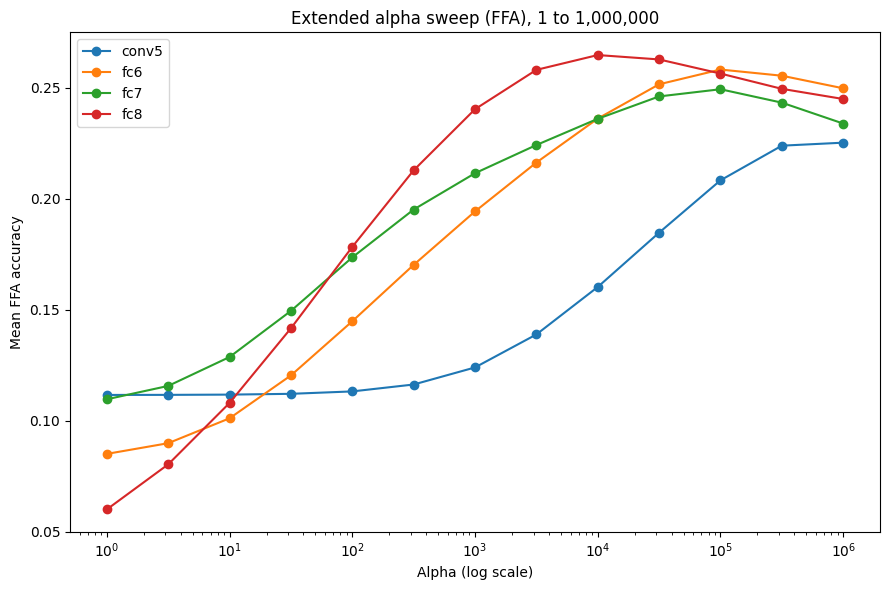


Check whether each layer's curve has leveled off (plateaued) or
started declining by alpha=1,000,000. If still rising at the far
right edge, extend the range further (e.g. to 1e7 or 1e8).


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

for layer in layers_to_check:
    subset = alpha_df[alpha_df["layer"] == layer]
    ax.plot(subset["alpha"], subset["mean_accuracy"], marker="o", label=layer)

ax.set_xscale("log")
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("Mean FFA accuracy")
ax.set_title("Extended alpha sweep (FFA), 1 to 1,000,000")
ax.legend()
fig.tight_layout()

os.makedirs("results/figures/alexnet", exist_ok=True)
fig.savefig("results/figures/alexnet/alpha_sensitivity_extended.png", dpi=150)
plt.show()

print("\nCheck whether each layer's curve has leveled off (plateaued) or")
print("started declining by alpha=1,000,000. If still rising at the far")
print("right edge, extend the range further (e.g. to 1e7 or 1e8).")

## Best alpha per layer

In [ ]:
os.makedirs("results/tables/alexnet", exist_ok=True)

best_alpha_per_layer = alpha_df.loc[alpha_df.groupby("layer")["mean_accuracy"].idxmax()]
print(best_alpha_per_layer)

best_alpha_per_layer.to_csv("results/tables/alexnet/best_alpha_per_layer_ffa.csv", index=False)

    layer      alpha  mean_accuracy
12  conv5  1000000.0       0.225241
23    fc6   100000.0       0.258173
36    fc7   100000.0       0.249302
47    fc8    10000.0       0.264699


In [ ]:
from google.colab import files

files.download("results/figures/alexnet/alpha_sensitivity_extended.png")
files.download("results/tables/alexnet/best_alpha_per_layer_ffa.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>